In [1]:
import torch
from torch import nn
import torchvision.transforms as transforms
import pandas as pd
import sys
from pathlib import Path

labels = pd.read_csv('../cifar-10/trainLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset, split_dataset

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=labels,
    transform=transforms.ToTensor()
)

train_dataset, val_dataset, test_dataset = split_dataset(
    dataset=train_dataset,
    train_size=int(0.8 * len(train_dataset)),
    val_size=int(0.1 * len(train_dataset)),
    test_size=int(0.1 * len(train_dataset))
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = create_dataloader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
from src.models import CIFARBaseline

model = CIFARBaseline().to(device)
model

CIFARBaseline(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [6]:
from src.metrics import create_metrics

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

In [7]:
from src.engine import fit

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001
)
epochs = 10

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Baseline.pt'
)

history


Epoch 1/10:
Training Loss: 1.5046 | Training Accuracy: 45.05% | Training Precision: 44.40% | Training Recall: 45.05%
Validation Loss: 1.1467 | Validation Accuracy: 59.93% | Validation Precision: 60.98% | Validation Recall: 59.93%
Best model saved! Val Acc: 59.93%

Epoch 2/10:
Training Loss: 1.0380 | Training Accuracy: 63.11% | Training Precision: 62.78% | Training Recall: 63.11%
Validation Loss: 0.9297 | Validation Accuracy: 66.83% | Validation Precision: 68.01% | Validation Recall: 66.83%
Best model saved! Val Acc: 66.83%

Epoch 3/10:
Training Loss: 0.8221 | Training Accuracy: 71.29% | Training Precision: 71.11% | Training Recall: 71.29%
Validation Loss: 0.8400 | Validation Accuracy: 70.94% | Validation Precision: 72.01% | Validation Recall: 70.94%
Best model saved! Val Acc: 70.94%

Epoch 4/10:
Training Loss: 0.6577 | Training Accuracy: 76.98% | Training Precision: 76.86% | Training Recall: 76.98%
Validation Loss: 0.8550 | Validation Accuracy: 71.15% | Validation Precision: 72.98% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.504595,0.450461,0.443960,0.450461,1.146710,0.599272,0.609841,0.599272
1,2,1.037994,0.631135,0.627834,0.631135,0.929723,0.668252,0.680059,0.668252
2,3,0.822139,0.712881,0.711124,0.712881,0.840023,0.709375,0.720111,0.709375
3,4,0.657692,0.769761,0.768573,0.769761,0.854975,0.711465,0.729838,0.711465
4,5,0.525159,0.814301,0.813622,0.814301,0.846358,0.720174,0.726796,0.720174
5,6,0.404791,0.857554,0.856948,0.857554,0.946109,0.712414,0.722820,0.712414
6,7,0.310874,0.889047,0.888687,0.889047,1.001042,0.715538,0.721221,0.715538
7,8,0.231765,0.917473,0.917237,0.917473,1.206138,0.703257,0.716294,0.703257
8,9,0.180944,0.936929,0.936793,0.936929,1.369611,0.699639,0.699127,0.699639
9,10,0.145199,0.948991,0.948922,0.948991,1.431743,0.702836,0.708218,0.702836


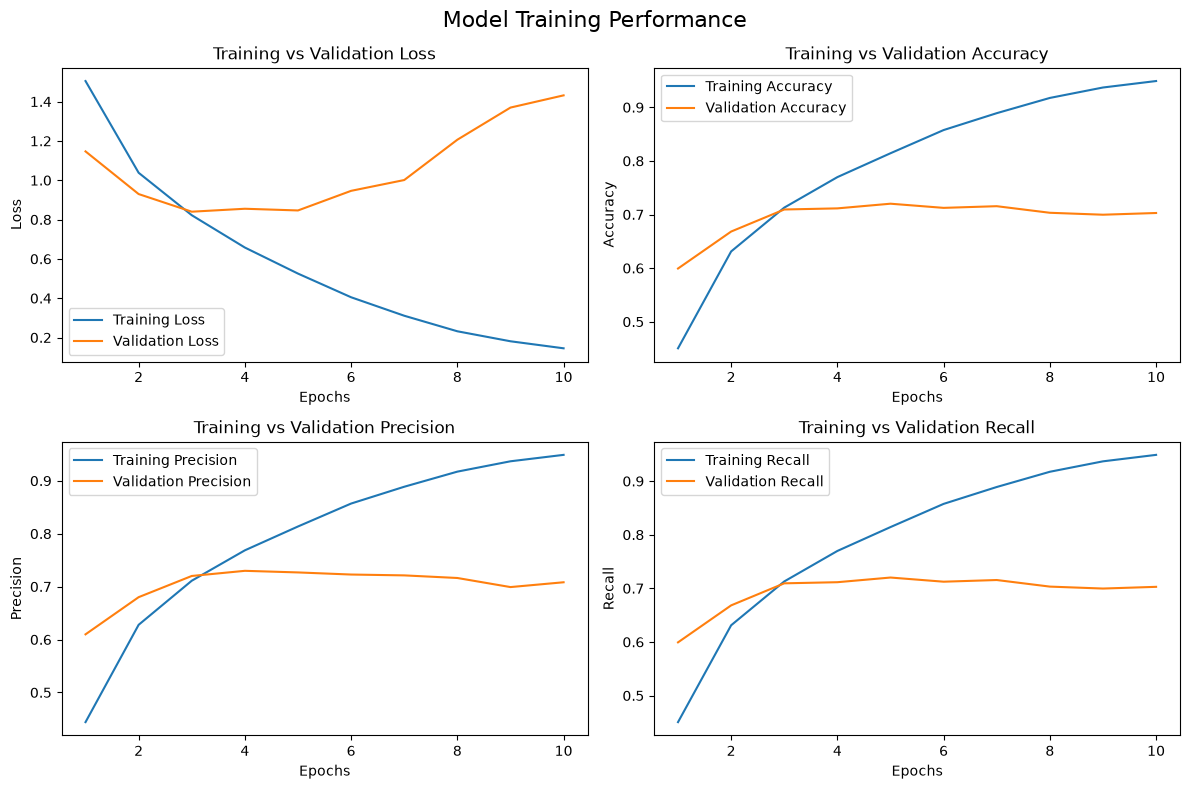

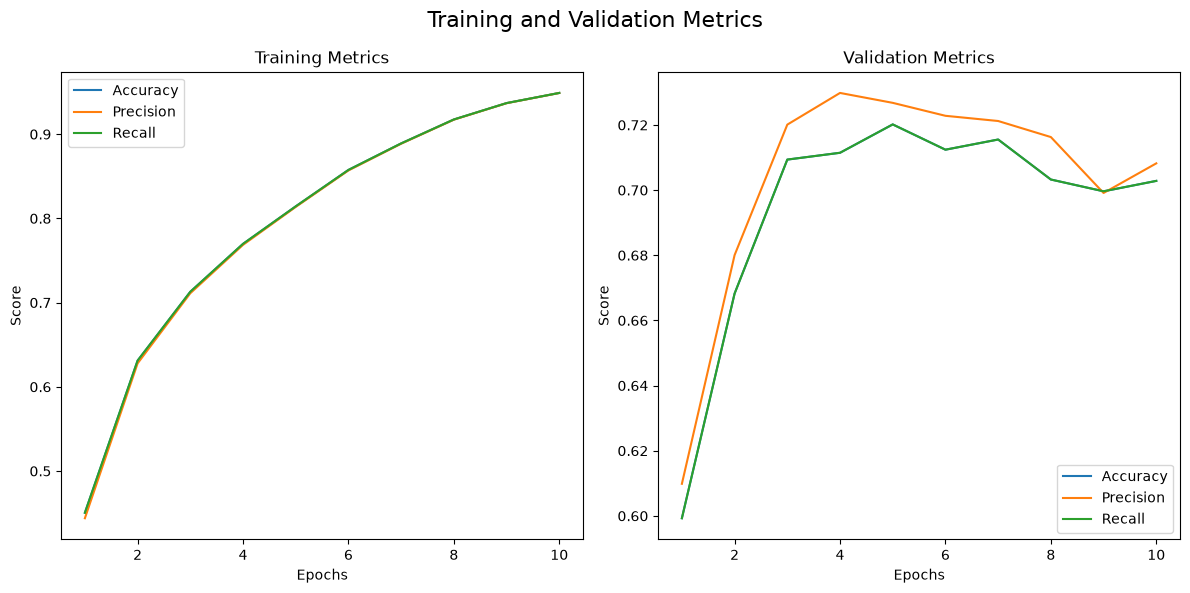

In [39]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)